In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.interpolate import interp1d

In [3]:
df = pd.read_csv("Nat_Gas.csv")

df['Dates'] = pd.to_datetime(df['Dates'])

df = df.sort_values('Dates')

df.head()

C:\Users\Krish\AppData\Local\Temp\ipykernel_22828\903803512.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


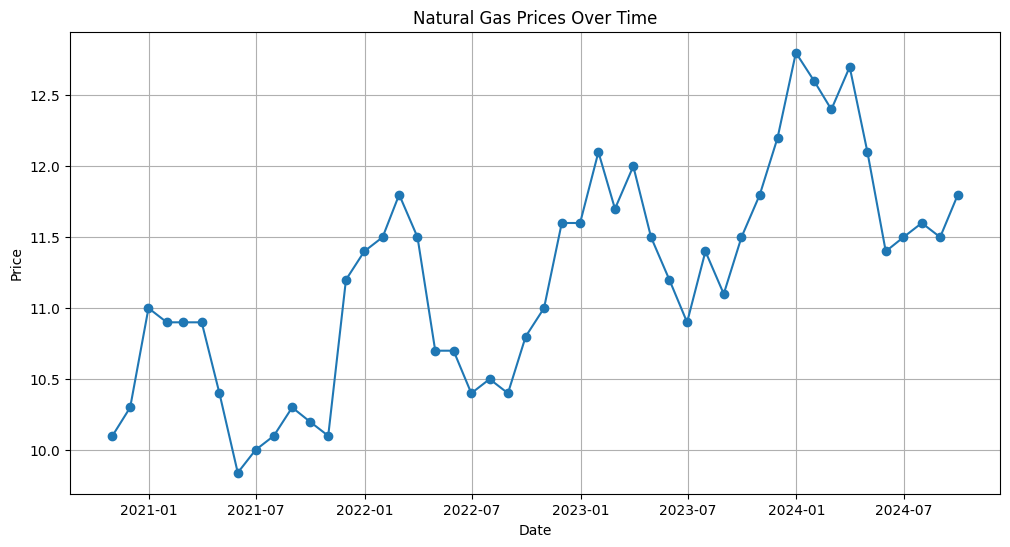

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Dates'], df['Prices'], marker='o')

plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)

plt.show()

In [5]:
df['TimeIndex'] = np.arange(len(df))

X = df[['TimeIndex']]
y = df['Prices']

In [6]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
future_months = 12

future_index = np.arange(len(df), len(df) + future_months)

future_prices = model.predict(future_index.reshape(-1,1))

c:\Users\Krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
last_date = df['Dates'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_months,
    freq='ME'
)

In [10]:
future_df = pd.DataFrame({
    'Dates': future_dates,
    'Prices': future_prices
})

combined_df = pd.concat([df[['Dates','Prices']], future_df])

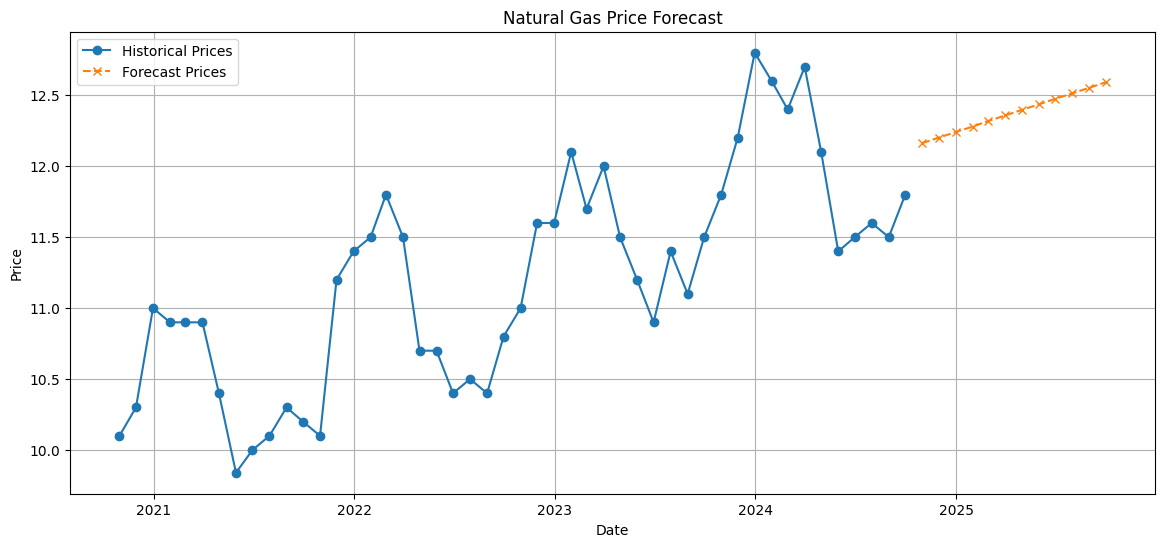

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df['Dates'], df['Prices'],
         label='Historical Prices',
         marker='o')

plt.plot(future_df['Dates'], future_df['Prices'],
         label='Forecast Prices',
         linestyle='--',
         marker='x')

plt.title("Natural Gas Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
date_ordinals = combined_df['Dates'].map(pd.Timestamp.toordinal)

prices = combined_df['Prices']

price_function = interp1d(
    date_ordinals,
    prices,
    fill_value="extrapolate"
)

def estimate_price(input_date):

    input_date = pd.to_datetime(input_date)

    ordinal_date = input_date.toordinal()

    estimated_price = float(price_function(ordinal_date))

    return round(estimated_price, 2)

In [13]:
date = "2025-06-15"

estimated = estimate_price(date)

print(f"Estimated gas price on {date}: ${estimated}")

Estimated gas price on 2025-06-15: $12.46


In [14]:
import pandas as pd

# -------------------------------------------------
# STORAGE CONTRACT PRICING FUNCTION
# -------------------------------------------------

def price_gas_contract(
    injection_dates,
    withdrawal_dates,
    injection_prices,
    withdrawal_prices,
    injection_rate,
    withdrawal_rate,
    max_storage_volume,
    storage_cost_per_month
):
    
    total_value = 0
    
    current_storage = 0
    
    total_storage_cost = 0

    # -----------------------------
    # HANDLE INJECTIONS
    # -----------------------------
    
    for i in range(len(injection_dates)):
        
        inject_date = pd.to_datetime(injection_dates[i])
        
        withdraw_date = pd.to_datetime(withdrawal_dates[i])
        
        buy_price = injection_prices[i]
        
        sell_price = withdrawal_prices[i]
        
        # Volume injected
        injected_volume = injection_rate
        
        # Ensure storage limit not exceeded
        if current_storage + injected_volume > max_storage_volume:
            
            injected_volume = (
                max_storage_volume - current_storage
            )
        
        current_storage += injected_volume
        
        # Revenue and purchase cost
        purchase_cost = buy_price * injected_volume
        
        sale_revenue = sell_price * injected_volume
        
        # Storage duration
        storage_months = (
            (withdraw_date.year - inject_date.year) * 12
            +
            (withdraw_date.month - inject_date.month)
        )
        
        # Storage costs
        storage_cost = (
            storage_months
            * storage_cost_per_month
        )
        
        total_storage_cost += storage_cost
        
        # Profit from this cycle
        trade_value = (
            sale_revenue
            - purchase_cost
            - storage_cost
        )
        
        total_value += trade_value
        
        # Withdraw gas
        withdrawn_volume = min(
            withdrawal_rate,
            current_storage
        )
        
        current_storage -= withdrawn_volume

    return {
        "Total Contract Value": round(total_value, 2),
        "Total Storage Cost": round(total_storage_cost, 2),
        "Remaining Gas Volume": round(current_storage, 2)
    }

In [15]:
# -----------------------------------------
# SAMPLE INPUTS
# -----------------------------------------

injection_dates = [
    "2025-05-01",
    "2025-06-01"
]

withdrawal_dates = [
    "2025-11-01",
    "2025-12-01"
]

# Use estimated prices from Task 1

injection_prices = [
    estimate_price("2025-05-01"),
    estimate_price("2025-06-01")
]

withdrawal_prices = [
    estimate_price("2025-11-01"),
    estimate_price("2025-12-01")
]

# Contract assumptions
injection_rate = 500000

withdrawal_rate = 500000

max_storage_volume = 1000000

storage_cost_per_month = 100000

# -----------------------------------------
# RUN MODEL
# -----------------------------------------

result = price_gas_contract(
    injection_dates,
    withdrawal_dates,
    injection_prices,
    withdrawal_prices,
    injection_rate,
    withdrawal_rate,
    max_storage_volume,
    storage_cost_per_month
)

print(result)

{'Total Contract Value': -970000.0, 'Total Storage Cost': 1200000, 'Remaining Gas Volume': 0}
